In [1]:
import os
for root, dirs, files in os.walk('/kaggle/input/'):
    for f in files:
        print(os.path.join(root, f))


/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-python.tar.gz
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_1
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_2
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/batches.meta
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/test_batch
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_3
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_5
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_4
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/readme.html


# implementing RESNET 18 on CIFAR 10

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

## Basic Block:
    - each block has two 3x3 conv layers with batch normalization
    - input is added back to output via residual connection
    - if dimensions dont match we use a 1x1 conv projection to resize the input

In [3]:
class Basicblock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super(Basicblock, self).__init__()

        # first conv: may downsample if stride=2
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
            stride=stride, padding=1, bias=False)  # bias=False because batchnorm has its own bias
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # second conv: always keeps the same spatial size
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
            stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # projection shortcut — needed when dimensions change
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                    stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # resize shortcut if needed
        if self.downsample is not None:
            identity = self.downsample(identity)

        out += identity  # residual connection
        out = self.relu(out)
        return out


## Resnet model(18):
    - stem(3x3) - 4 layers of basic blocks - global average pooling - claissfier
    - we use 3x3 instead of standard 7x7 because images are already small and we dont want to lose spatial info
    - each layer has 2 basic blocks

In [4]:
class ResNet(nn.Module):

    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64

        # stem — 3x3 conv for CIFAR-10 (no maxpool)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # layers
        self.layer1 = self._make_layer(block, 64,  num_blocks[0], stride=1)  # 32x32
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)  # 16x16
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)  # 8x8
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)  # 4x4

        # classifier head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        # first block downsample
        layers = []
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)  # flatten
        out = self.fc(out)
        return out

def ResNet18(num_classes=10):
    return ResNet(Basicblock, [2, 2, 2, 2], num_classes)


## shape test

In [5]:
model = ResNet18()
test_input = torch.randn(1, 3, 32, 32)
test_output = model(test_input)
print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {test_output.shape}")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
del model  


Input shape:  torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 10])
Total parameters: 11,173,962


## data loading
- random crop (32x32 with padding=4)
- random horizontal flip
- normalization using CIFAR-10 mean and std values

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

batch_size = 128

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

DATA_ROOT = '/kaggle/input/datasets/pankrzysiu/cifar10-python/'

train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT, train=True, download=False, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT, train=False, download=False, transform=test_transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Using device: cuda
Training samples: 50000
Test samples: 10000


## SGD with momentum, 30 epochs

In [7]:
num_epochs = 30

model = ResNet18(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)


## training loop

In [8]:
def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # update
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


def test():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100.0 * correct / total


In [9]:
train_losses = []
test_accuracies = []
best_accuracy = 0.0

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(epoch)
    test_acc = test()
    scheduler.step()

    train_losses.append(train_loss)
    test_accuracies.append(test_acc)

    if test_acc > best_accuracy:
        best_accuracy = test_acc
        torch.save(model.state_dict(), '/kaggle/working/best_resnet18.pth')

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch:2d}/{num_epochs}]  "
          f"Loss: {train_loss:.4f}  "
          f"Train Acc: {train_acc:.2f}%  "
          f"Test Acc: {test_acc:.2f}%  "
          f"LR: {current_lr:.6f}")

print(f"\nBest Test Accuracy: {best_accuracy:.2f}%")


Epoch [ 1/30]  Loss: 1.8665  Train Acc: 32.55%  Test Acc: 43.74%  LR: 0.099726
Epoch [ 2/30]  Loss: 1.4112  Train Acc: 48.32%  Test Acc: 50.19%  LR: 0.098907
Epoch [ 3/30]  Loss: 1.1630  Train Acc: 58.22%  Test Acc: 63.78%  LR: 0.097553
Epoch [ 4/30]  Loss: 0.9710  Train Acc: 65.53%  Test Acc: 66.71%  LR: 0.095677
Epoch [ 5/30]  Loss: 0.8331  Train Acc: 70.71%  Test Acc: 70.65%  LR: 0.093301
Epoch [ 6/30]  Loss: 0.7010  Train Acc: 75.65%  Test Acc: 72.90%  LR: 0.090451
Epoch [ 7/30]  Loss: 0.6195  Train Acc: 78.56%  Test Acc: 76.70%  LR: 0.087157
Epoch [ 8/30]  Loss: 0.5611  Train Acc: 80.67%  Test Acc: 80.42%  LR: 0.083457
Epoch [ 9/30]  Loss: 0.5211  Train Acc: 82.07%  Test Acc: 78.91%  LR: 0.079389
Epoch [10/30]  Loss: 0.4863  Train Acc: 83.08%  Test Acc: 81.23%  LR: 0.075000
Epoch [11/30]  Loss: 0.4579  Train Acc: 84.14%  Test Acc: 77.85%  LR: 0.070337
Epoch [12/30]  Loss: 0.4310  Train Acc: 85.32%  Test Acc: 79.31%  LR: 0.065451
Epoch [13/30]  Loss: 0.4061  Train Acc: 86.07%  Test

## results

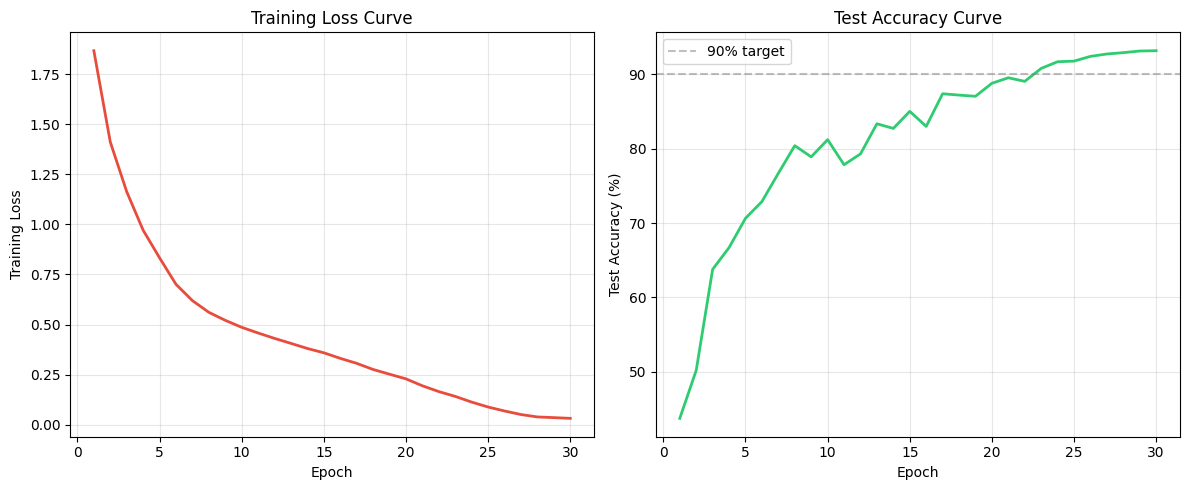

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(range(1, num_epochs + 1), train_losses, color='#e74c3c', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Curve')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, num_epochs + 1), test_accuracies, color='#2ecc71', linewidth=2)
ax2.axhline(y=90, color='gray', linestyle='--', alpha=0.5, label='90% target')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Test Accuracy Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/loss_accuracy_curves.png', dpi=150)
plt.show()
